# Building Floor Area & Thermal Index Panel (2010-2060)

The EU Building Stock Observatory (BSO) only has a single snapshot of useful floor area and its
cohort distribution, for 2020. Both the heat-pump model (`heat_pump_ols.ipynb`) and the
buildings-rest model (`buildings_rest_ols.ipynb`) need `total_floor_m2` and `thermal_index` as
annual features for 2010-2060, so this notebook builds that panel and exports it as a CSV.

**History and projection are kept strictly separate:**

| Period | Method | Driven by | Scenario-dependent? |
|---|---|---|---|
| 2010-2024 | Backcasting from the 2020 snapshot | observed construction activity (Eurostat building permits) | no |
| 2025-2060 | Forward projection | demand drivers + renovation/demolition rates | yes |

Reason: the PanelOLS models are trained on the historical period, so it should carry as little
assumption-driven variation as possible - otherwise the estimated coefficients partly reflect
our own assumptions instead of observed relationships. It also means the sensitivity analysis on
projection parameters (§5) doesn't touch the training data or require re-fitting the model.

**Method family.** The forward model follows the dynamic building stock / dynamic
material-flow-analysis (dMFA) tradition: a stock split into construction-year cohorts, evolving
through three flows - construction, demolition, renovation - with construction set by a
demand-side driver rather than being a free parameter:

> Sartori, I., Sandberg, N. H., & Brattebø, H. (2016). Dynamic building stock modelling: General
> algorithm and exemplification for Norway. Energy and Buildings, 132, 13-25.
> https://doi.org/10.1016/j.enbuild.2016.05.098 (open access)
>
> Sandberg, N. H., Sartori, I., Heidrich, O., Dawson, R., Dascalaki, E., Dimitriou, S., Vimm-r,
> T., Filippidou, F., Stegnar, G., Šijanec Zavrl, M., & Brattebø, H. (2016). Dynamic building
> stock modelling: Application to 11 European countries to support the energy efficiency and
> retrofit ambitions of the EU. Energy and Buildings, 132, 26-38.

**Outputs**
- `Data - raw/prepared_data/floor_panel_2010_2060.csv` - the panel both models read
- diagnostic plots and a sensitivity analysis of the projection parameters

---


## 1. Setup and configuration

All modelling assumptions in one place so they're easy to cite and vary.

In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

West_EU  = ["Germany", "France", "Belgium", "Netherlands", "Luxembourg", "Austria", "Ireland"]
East_EU  = ["Bulgaria", "Hungary", "Czechia", "Poland", "Romania", "Slovakia"]
South_EU = ["Spain", "Slovenia", "Portugal", "Italy", "Croatia", "Greece"]
Nord_EU  = ["Denmark", "Sweden", "Norway", "Finland", "Estonia", "Latvia", "Lithuania"]
ALL_COUNTRIES = sorted(West_EU + East_EU + South_EU + Nord_EU)

# ---- file paths (same conventions as the two model notebooks) -----------------
PATH_BSO        = "Heat Pump/heat_pumps.xlsx"
SHEET_BSO       = "heat_spec_distribution"
PATH_NORWAY     = "Heat Pump/Norway_building_floor_data.xlsx"
SHEET_NORWAY    = "Norway_floor_data_2020"
PATH_PANEL      = "Data - raw/prepared_data/panel_transformed.csv"
PATH_PERMITS_CACHE = "Data - raw/prepared_data/eurostat_sts_cobp_a_cache.csv"
PATH_OUT        = "Data - raw/prepared_data/floor_panel_2010_2060.csv"
BUILDING_PERMIT_PATH = "Data - raw/eurostat_building_permits.csv"

HIST_YEARS = list(range(2010, 2025))     # 2010-2024, observation-based
PROJ_YEARS = [2025, 2026, 2027, 2028, 2029, 2030, 
              2035, 2040, 2045, 2050, 2055, 2060]
#PROJ_YEARS = list(range(2025, 2061))     # 2025-2060, assumption-based
BSO_YEAR   = 2020                        # the year the BSO snapshot refers to

print(f"{len(ALL_COUNTRIES)} countries | history {HIST_YEARS[0]}-{HIST_YEARS[-1]} "
      f"| projection {PROJ_YEARS[0]}-{PROJ_YEARS[-1]}")

26 countries | history 2010-2024 | projection 2025-2060


### 1.1 Cohorts and heat-demand intensities

Each construction-year cohort gets a heat-demand intensity in kWh/m²a, representing typical
space-heating demand of that period's building fabric. Should be calibrated against the
TABULA/EPISCOPE national building typologies (https://episcope.eu/building-typology/). Values
below match what the existing model notebooks already use, kept unchanged for comparability.

Two cohorts don't exist in the BSO snapshot and are added here:

* `post-2020` - new construction after the snapshot year, 35 kWh/m²a, the nearly-zero-energy
  building (NZEB) requirement for all new EU buildings since 2021 (EPBD, Directive 2010/31/EU
  Art. 9).
* `ren_<cohort>` - floor area of a cohort that's been energy-renovated. Its intensity comes from
  the source cohort (§1.3), not a flat value - a renovated 1920s building isn't a new building.

In [27]:
BSO_COHORTS = ["0-1945", "1946-1969", "1970-1979", "1980-1989",
               "1990-1999", "2000-2010", "2011-2020"]
NEW_COHORT  = "post-2020"
REN_PREFIX  = "ren_"

# heat-demand intensity by construction cohort, kWh/m2a (calibrate against TABULA)
# tunable via scenario_config.py (single source of truth, also used by
# heat_pump_ols.ipynb's thermal_index chart and praesentation_grafiken.ipynb)
from scenario_config import BASE_INTENSITY

# column names in the BSO sheet
PERIOD_COLS = {
    "0-1945": "anteil 0-1945", "1946-1969": "anteil 1946-1969",
    "1970-1979": "anteil 1970-1979", "1980-1989": "anteil 1980-1989",
    "1990-1999": "anteil 1990-1999", "2000-2010": "anteil 2000-2010",
    "2011-2020": "anteil 2011-now",
}

### 1.2 Demolition

Modelled as an age-dependent annual hazard rate rather than a flat share of the stock - older
buildings are more likely to leave the stock. The dMFA literature usually fits a Weibull (or
log-normal) survival function to observed demolition data:

> Miatto, A., Schandl, H., & Tanikawa, H. (2017). How important are realistic building lifespan
> assumptions for material stock and demolition waste accounts? Resources, Conservation and
> Recycling, 122, 143-154.
>
> Sandberg, N. H., Sartori, I., & Brattebø, H. (2014) - Weibull demolition probability applied to
> national dwelling stocks.

Fitting country-specific Weibull parameters needs observed demolition micro-data, which Eurostat
doesn't publish for all 26 countries. So instead we use a step approximation of the hazard: a
small constant rate per cohort, increasing with age, chosen so the stock-wide average stays in
the ~0.1-0.2%/yr range usually quoted for European building stocks.

> To verify before writing up: check that 0.1-0.2%/yr figure against a citable source (e.g. the
> country tables in Sandberg et al. 2016, or national statistics like Destatis for Germany). §6
> quantifies how much this choice actually matters.

In [28]:
# annual demolition hazard by cohort (step approximation of an age-dependent hazard)
# tunable via scenario_config.py
from scenario_config import DEMOLITION_RATE

### 1.3 Renovation

Modelled as a mass-preserving shift between cohorts: renovated area stays in the stock (it isn't
demolished) but moves into a class with lower heat-demand intensity. This is the main change
from the previous implementation, where the "renovation rate" removed area from the stock
entirely and effectively acted as a second demolition term.

Two parameters:

**(a) Renovation rate** - share of stock renovated per year:

| Indicator | Value | Source |
|---|---|---|
| Weighted annual energy renovation rate, EU | ~1%/yr (0.4-1.2% by Member State) | European Commission / BPIE |
| Annual deep renovation rate, residential | 0.2%/yr | BPIE (2021) |
| Annual deep renovation rate, non-residential | 0.3%/yr | BPIE (2021) |
| Renovation Wave target | at least double, ~2%/yr by 2030 | COM(2020) 662 final |
| BPIE recommendation for climate neutrality | 3%/yr deep renovation | BPIE (2021) |

> BPIE (2021). Deep Renovation: Shifting from exception to standard practice in EU Policy.
> https://www.bpie.eu/publication/deep-renovation-shifting-from-exception-to-standard-practice-in-eu-policy/
>
> European Commission (2020). A Renovation Wave for Europe. COM(2020) 662 final.

**(b) Renovation depth** - how much a renovation cuts heat demand. The rate above covers energy
renovations of any depth, mostly shallow, so we apply an average relative reduction instead of
moving area to a new-build intensity:

$$\text{intensity}(\mathrm{ren\_}c) = \text{intensity}(c)\cdot(1-\text{depth})$$

`depth = 0.35` means the average renovation cuts fabric heat demand ~35%, between a shallow
measure (window/boiler swap, ~10-20%) and a deep retrofit (~60-90%, BPIE's deep-renovation
definition), weighted towards shallow since deep renovations are only ~0.2pp of the ~1%/yr total.

**Scenarios.** Population, GDP and floor area are identical across KKO/KVE/VWE/VNI, so the
renovation rate is the only channel through which the scenarios differ in the building-stock
panel. Mapped onto the same SSP storylines used for HDD/CDD:

| Scenario | SSP | Renovation rate by 2030 | Reading |
|---|---|---|---|
| KKO | SSP1 (sustainability) | 2.0%/yr | Renovation Wave target met |
| KVE | SSP2 (middle of the road) | 1.5%/yr | partial policy success |
| VWE | SSP5 (fossil-fuelled development) | 1.5%/yr | high build activity, moderate retrofit |
| VNI | SSP3 (regional rivalry) | 1.0%/yr | status quo persists |

All scenarios start at the current EU average of ~1%/yr in 2025 and ramp linearly to their 2030
value, then hold constant.

In [29]:
RENOVATABLE      = ["0-1945", "1946-1969", "1970-1979", "1980-1989", "1990-1999", "2000-2010"]

# renovation & scenario assumptions - tunable via scenario_config.py
from scenario_config import (
    RENOVATION_DEPTH,
    RENOVATION_START,
    SCENARIO_RENOVATION,
    CLIMATE_SCENARIO_MAP,
    HIST_RENOVATION_RATE,
)
SCENARIOS = list(SCENARIO_RENOVATION)

### 1.4 Demand-driven new construction

New construction isn't a free parameter - it's the residual that closes the mass balance between
demanded floor area and what survives demolition:

$$
\text{Target}(t) = \text{Population}(t)\cdot\text{FloorPerCapita}(t)
$$
$$
\text{NewBuild}(t) = \max\big(0,\ \text{Target}(t) - \text{StockAfterDemolition}(t)\big)
$$

This avoids the contradiction you get when growth, demolition and renovation are all set
independently (demolition could then exceed growth and shrink the stock even though demand says
it should grow), and it handles shrinking populations gracefully: falling demand sends new
construction to zero instead of negative, and the excess area just stays in the stock as
(implicitly) vacant, which is roughly what happens in reality. Demolition depends only on
building age, never on demand.

Floor area per capita is linked to income with a constant elasticity below one:

$$
\text{FloorPerCapita}(t) = \text{FloorPerCapita}(t_0)\cdot
\left(\frac{\text{GDP}_{pc}(t)}{\text{GDP}_{pc}(t_0)}\right)^{\varepsilon}
$$

Elasticity below one = saturation: richer households take more space, but not proportionally to
income. Instead of assuming ε, §5.1 estimates it from the reconstructed historical panel
(within-country regression of ln floor-per-capita on ln GDP per capita); the value below is only
a fallback if that estimate turns out implausible.

In [30]:
# income elasticity & permit-lag assumptions - tunable via scenario_config.py
from scenario_config import EPSILON_DEFAULT, EPSILON_BOUNDS, PERMIT_LAG

---
## 2. Input data

### 2.1 BSO 2020 snapshot

> EU Building Stock Observatory, https://energy.ec.europa.eu/topics/energy-efficiency/energy-performance-buildings/eu-building-stock-observatory_en
> Last update May 2026; the data itself is for 2020. Norway isn't covered by the BSO, taken from
> Statistics Norway (SSB) instead, prepared in the same format.

Gives total useful floor area (m²) per country and the share falling into each construction-year
cohort.

In [31]:
bso = pd.read_excel(PATH_BSO, sheet_name=SHEET_BSO)
bso = bso[:27]
bso = bso[bso.Country.isin(ALL_COUNTRIES)].set_index("Country")

norway_floor = pd.read_excel(PATH_NORWAY, sheet_name=SHEET_NORWAY, index_col=0)
bso = pd.concat([bso, norway_floor])

# integrity checks
share_sum = bso[list(PERIOD_COLS.values())].sum(axis=1)
assert np.allclose(share_sum, 1.0, atol=1e-3), "cohort shares do not sum to 1"
missing = sorted(set(ALL_COUNTRIES) - set(bso.index))
assert not missing, f"countries missing from BSO: {missing}"

print(f"BSO snapshot loaded: {len(bso)} countries, reference year {BSO_YEAR}")
print(f"total EU-26 useful floor area {bso['gesamtfläche_m2'].sum()/1e9:.1f} bn m2")
bso#.head()

BSO snapshot loaded: 26 countries, reference year 2020
total EU-26 useful floor area 22.2 bn m2


,gesamtfläche_m2,anteil 0-1945,anteil 1946-1969,anteil 1970-1979,anteil 1980-1989,anteil 1990-1999,anteil 2000-2010,anteil 2011-now
Country,,,,,,,,
Austria,480479871,0.226669,0.265689,0.153497,0.123125,0.141204,0.069105,0.02071
Belgium,693785280,0.411845,0.217941,0.121747,0.084841,0.064261,0.062943,0.036422
Bulgaria,321201659,0.20838,0.226748,0.145953,0.137376,0.107167,0.111183,0.063192
Croatia,182977135,0.129597,0.171136,0.183956,0.140586,0.128498,0.157216,0.089011
Czechia,387472106,0.178462,0.208683,0.203641,0.127887,0.087488,0.1155,0.078338
Denmark,341768565,0.206363,0.182657,0.200548,0.101004,0.100508,0.106585,0.102335
Estonia,27472583,0.330614,0.211147,0.085553,0.076144,0.117936,0.115091,0.063515
Finland,406877934,0.146812,0.234661,0.147952,0.186731,0.123418,0.133904,0.026521
France,3087013302,0.182696,0.141576,0.155983,0.149489,0.098669,0.147054,0.124533


### 2.2 Population and GDP panel

Same prepared panel the model notebooks use, so the floor-area projection's drivers stay
consistent with the drivers inside the PanelOLS models.

In [32]:
panel = pd.read_csv(PATH_PANEL)
panel = panel[panel.country.isin(ALL_COUNTRIES)]

need = ["country", "year", "population_Mio", "gdp_per_capita_USD"]
missing_cols = [c for c in need if c not in panel.columns]
assert not missing_cols, f"missing columns in {PATH_PANEL}: {missing_cols}"

drivers = panel[need].dropna().sort_values(["country", "year"]).reset_index(drop=True)
print("driver panel:", drivers.year.min(), "-", drivers.year.max(),
      "|", drivers.country.nunique(), "countries")

driver panel: 1990 - 2060 | 26 countries


### 2.3 Eurostat building permits - observed construction activity

Replaces the previous constant-annual-new-build assumption for the historical period. Instead of
spreading the BSO 2011-now cohort evenly over ten years, we distribute it by the observed shape
of construction activity - which was anything but flat: after the 2008 financial crisis,
permitted floor area collapsed 70-90% in Spain, Ireland, Greece and Portugal while staying
roughly stable in Germany and Poland.

Dataset: `sts_cobp_a` - Building permits, annual data (Eurostat, Short-Term Business Statistics).
Indicator `PSQM` = m² of useful floor area with permits issued. Series start around 2005 for
most countries. https://ec.europa.eu/eurostat/databrowser/view/sts_cobp_a

> Note: from 2025 Eurostat publishes building permits under a new statistic, *Building stock and
> new production*. If `sts_cobp_a` gets discontinued, check that dataset for a successor - the
> logic below only needs an annual, country-level series proportional to newly built floor area.

The permit series is used for its shape only - its level is calibrated so cumulative new build
2011-2020 exactly reproduces the BSO 2011-now cohort (§3.1), so an index series (2021=100) works
just as well as absolute m², which makes this robust to Eurostat's unit conventions.

Permits aren't completions: permitted buildings finish 1-2 years later and not all permits get
realised. We shift the series by `PERMIT_LAG` years; the un-realised share is absorbed by the
level calibration.

In [33]:
# Zotero Key: eurostat_building_permits
permits = pd.read_csv(BUILDING_PERMIT_PATH)

# only keeping needed columns
permits = permits[["Geopolitical entity (reporting)", "TIME_PERIOD", "OBS_VALUE"]]

permits= permits.rename(columns={
    "TIME_PERIOD": "year",
    "Geopolitical entity (reporting)": "country",
    "OBS_VALUE": "permit_value",
})  

# the values are in Million m2, so multiplying it to 10**6 to have them in m2, same as bso data
permits["permit_value"] = permits["permit_value"] * 1e6

permits

,country,year,permit_value
0,Austria,2010,6200000.0
1,Austria,2011,7000000.0
2,Austria,2012,6200000.0
3,Austria,2013,6800000.0
4,Austria,2014,6900000.0
...,...,...,...
411,Slovakia,2021,2600000.0
412,Slovakia,2022,2300000.0
413,Slovakia,2023,2000000.0
414,Slovakia,2024,1600000.0


---
## 3. Historical reconstruction 2010-2024 (backcasting)

### 3.1 Algorithm

The 2020 BSO snapshot is the anchor. From it we walk backwards to 2010 and forwards to 2024
using observed construction activity:

1. Calibrate the permit series to the snapshot: new build in year $t$ is
   $N_t = k\cdot P_{t-\text{lag}}$, $P$ the permit series, scale factor $k$ chosen so
   $\sum_{t=2011}^{2020} N_t$ equals the BSO 2011-now cohort exactly. This is what makes the
   permit series' units irrelevant and absorbs the permit-to-completion gap.
2. Backwards 2019 → 2010: undo demolition, $A_c(t) = A_c(t{+}1)/(1-d_c)$, remove year $t{+}1$'s
   new build from the 2011-2020 cohort. That cohort reaches exactly zero at 2010 by construction.
3. Forwards 2021 → 2024: apply demolition, add new build into `post-2020`.

No renovation by default:
* Observed deep renovation over 2010-2024 was ~0.2%/yr, under 3% of stock cumulatively -
  negligible for the area-weighted thermal index.
* No data on which buildings were renovated, so any historical renovation term would be pure
  assumption baked into the model's training data.
* Keeps the estimated `ln_thermal_index` coefficient reflecting observed variation only.

Optional historical renovation (togglable): `HIST_RENOVATION_RATE`, imported from
`scenario_config.py` (tune via `PARAMS["HIST_RENOVATION_RATE"]` in `run_full_pipeline.ipynb`,
like the other renovation parameters). `0.0` gives the assumption-free reconstruction above; e.g.
`0.01` applies a flat 1%/yr renovation using the same mass-preserving, worst-first mechanism as
the projection (§4.2), accumulating forward from 2010 (0% renovated) through 2024 - so the
further back, the less renovated the stock. Renovated and un-renovated area share the same
demolition hazard, so total floor area per cohort at every year (including the 2020 anchor) is
untouched by the rate; only the raw/`ren_` split and the derived `thermal_index` change.

In [34]:
def empty_state():
    st = {c: 0.0 for c in BSO_COHORTS}
    st[NEW_COHORT] = 0.0
    for c in RENOVATABLE:
        st[REN_PREFIX + c] = 0.0
    return st

def intensity_of(cohort, depth=RENOVATION_DEPTH):
    """Heat-demand intensity (kWh/m2a) of any cohort key, including renovated ones."""
    if cohort.startswith(REN_PREFIX):
        return BASE_INTENSITY[cohort[len(REN_PREFIX):]] * (1.0 - depth)
    return BASE_INTENSITY[cohort]

def thermal_index(area, depth=RENOVATION_DEPTH):
    """Area-weighted average heat-demand intensity of a stock state."""
    tot = sum(area.values())
    if tot <= 0:
        return np.nan
    return sum(a * intensity_of(c, depth) for c, a in area.items()) / tot


def backcast_history(bso_row, permit_shape, years=HIST_YEARS,
                     demolition=DEMOLITION_RATE, lag=PERMIT_LAG):
    """Reconstruct 2010-2024 from the BSO 2020 snapshot and an observed permit shape.

    Parameters
    ----------
    bso_row      : row of the BSO table (total floor area + cohort shares)
    permit_shape : dict {year: value}; only the shape is used, the level is calibrated
    Returns
    -------
    states    : {year: {cohort: m2}}
    new_build : {year: m2} implied annual new construction
    k         : calibration factor (m2 per unit of permit series)
    """
    At = bso_row["gesamtfläche_m2"]
    a2020 = empty_state()
    for c in BSO_COHORTS[:-1]:
        a2020[c] = bso_row[PERIOD_COLS[c]] * At
    a2020["2011-2020"] = bso_row[PERIOD_COLS["2011-2020"]] * At

    build_years = list(range(2011, BSO_YEAR + 1))
    vals = [permit_shape.get(y - lag, np.nan) for y in build_years]
    if not np.all(np.isfinite(vals)) or np.nansum(vals) <= 0:
        raise ValueError("permit shape incomplete for the 2011-2020 calibration window")
    k = a2020["2011-2020"] / float(np.nansum(vals))
    new_build = {y: k * permit_shape[y - lag]
                 for y in range(2011, max(years) + 1)
                 if np.isfinite(permit_shape.get(y - lag, np.nan))}

    states = {BSO_YEAR: dict(a2020)}

    for y in range(BSO_YEAR - 1, min(years) - 1, -1):          # backwards
        prev = dict(states[y + 1])
        for c in BSO_COHORTS[:-1]:
            d = demolition.get(c, 0.0)
            if d > 0:
                prev[c] = prev[c] / (1.0 - d)
        prev["2011-2020"] = max(0.0, prev["2011-2020"] - new_build.get(y + 1, 0.0))
        states[y] = prev

    for y in range(BSO_YEAR + 1, max(years) + 1):              # forwards
        cur = dict(states[y - 1])
        for c in BSO_COHORTS[:-1]:
            cur[c] *= (1.0 - demolition.get(c, 0.0))
        cur[NEW_COHORT] += new_build.get(y, 0.0)
        states[y] = cur

    return {y: states[y] for y in years}, new_build, k


def apply_renovation_history(states, years, rate,
                             renovatable=RENOVATABLE, demolition=DEMOLITION_RATE):
    """Split a renovation-free backcast into un-renovated / `ren_` portions.

    Mirrors the mass-preserving, worst-first shift used in the projection (§4.2): each year
    `rate * total_stock` moves from the oldest renovatable cohorts into their `ren_`
    counterpart, accumulating monotonically forward in time starting from `min(years)`
    (2010, 0 % renovated). Renovated and un-renovated area share the same demolition
    hazard, so the per-cohort totals already produced by `backcast_history` - including the
    2020 BSO anchor - are left untouched; only the raw/`ren_` split (and hence the derived
    thermal_index) changes.
    """
    if rate <= 0:
        return states
    out = {}
    carried = {c: 0.0 for c in renovatable}
    for y in sorted(years):
        raw = states[y]
        cur = dict(raw)
        to_renovate = rate * sum(raw.values())
        for c in renovatable:
            d = demolition.get(c, 0.0)
            carried[c] *= (1.0 - d)                       # last year's ren_ area ages too
            available = max(0.0, raw.get(c, 0.0) - carried[c])
            take = min(available, to_renovate)
            carried[c] += take
            to_renovate -= take
        for c in renovatable:
            cur[c] = raw.get(c, 0.0) - carried[c]
            cur[REN_PREFIX + c] = carried[c]
        out[y] = cur
    return out

### 3.2 Run the backcast for all countries

In [35]:
REQ_YEARS = [y - PERMIT_LAG for y in range(2011, BSO_YEAR + 1)]

In [36]:
def permit_dict(country, permits_df):
    """Permit shape for one country; flat fallback if coverage is insufficient."""
    g = permits_df[permits_df.country == country]
    d = dict(zip(g["year"], g["permit_value"]))
    if all(np.isfinite(d.get(y, np.nan)) for y in REQ_YEARS):
        return d, "permits"
    return {y: 1.0 for y in REQ_YEARS}, "flat_fallback"


hist_states, hist_meta, hist_newbuild = {}, {}, {}
for country in ALL_COUNTRIES:
    shape, method = permit_dict(country, permits)
    states, nb, k = backcast_history(bso.loc[country], shape)
    states = apply_renovation_history(states, HIST_YEARS, HIST_RENOVATION_RATE)
    hist_states[country]   = states
    hist_newbuild[country] = nb
    hist_meta[country]     = method

print(pd.Series(hist_meta).value_counts().to_string())

def states_to_frame(states_by_country, scenario=None):
    rows = []
    for country, states in states_by_country.items():
        for year, area in states.items():
            tot = sum(area.values())
            row = {"country": country, "year": year,
                   "total_floor_m2": tot,
                   "thermal_index": thermal_index(area)}
            if scenario is not None:
                row["scenario"] = scenario
            for c, a in area.items():
                row[f"share_{c}"] = a / tot if tot > 0 else np.nan
            rows.append(row)
    return pd.DataFrame(rows)

floor_hist = states_to_frame(hist_states)
floor_hist["hist_method"] = floor_hist["country"].map(hist_meta)
print("\nhistorical panel:", floor_hist.shape)
floor_hist[floor_hist.country == "Spain"][
    ["year", "total_floor_m2", "thermal_index"]].head(15)

permits    26

historical panel: (390, 19)


,year,total_floor_m2,thermal_index
360,2010,3.474055e+09,160.976186
361,2011,3.512072e+09,159.597537
362,2012,3.543199e+09,158.459361
363,2013,3.566514e+09,157.576507
364,2014,3.577648e+09,157.068817
365,2015,3.589940e+09,156.530317
366,2016,3.604080e+09,155.941558
367,2017,3.626966e+09,155.103726
368,2018,3.653999e+09,154.158444
369,2019,3.689319e+09,152.995577


### 3.3 Validation of the historical reconstruction

**(a) Snapshot reproduction.** The 2020 state has to reproduce the BSO input exactly - a
consistency check on the algorithm, not the data.

**(b) Independent cross-check.** Cumulative permitted floor area 2011-2020 vs. the BSO 2011-now
cohort - two independent sources; agreement within a plausible realisation rate supports the
reconstruction, strong divergence flags a suspect cohort share or permit series. Only meaningful
when the permit series is in absolute m² - with an index series the ratio is arbitrary and only
the relative ranking across countries carries information.

**(c) Floor area per capita.** Should be plausible (roughly 35-60 m² per person for European
residential stocks) and evolve smoothly.

In [37]:
"""# (a) snapshot reproduction
# residual error stems from rounding in the BSO share columns (they sum to 1 only to ~1e-6),
# not from the algorithm: the reconstructed 2020 state is the cohort decomposition itself
err = []
for country in ALL_COUNTRIES:
    got = sum(hist_states[country][BSO_YEAR].values())
    exp = bso.loc[country, "gesamtfläche_m2"]
    err.append(abs(got - exp) / exp)
print(f"(a) max relative error reproducing the {BSO_YEAR} snapshot: {max(err):.2e}")
print(f"    (max deviation of the BSO shares from 1.0: {abs(share_sum - 1).max():.2e})")
assert max(err) < 1e-4

# (b) permits vs BSO cohort
chk = []
for country in ALL_COUNTRIES:
    if hist_meta[country] != "permits":
        continue
    g = permits[(permits.country == country) &
                       (permits.year.between(2011 - PERMIT_LAG, 2020 - PERMIT_LAG))]
    chk.append({"country": country,
                "permits_cum": g["permit_value"].sum(),
                "bso_cohort_m2": bso.loc[country, PERIOD_COLS["2011-2020"]] *
                                 bso.loc[country, "gesamtfläche_m2"]})
chk = pd.DataFrame(chk)
if len(chk):
    chk["ratio_bso_over_permits"] = chk["bso_cohort_m2"] / chk["permits_cum"]
    print("\n(b) BSO cohort / cumulative permits  (constant across countries => consistent units)")
    display(chk.set_index("country").sort_values("ratio_bso_over_permits").round(3))

# (c) floor per capita
fpc = (floor_hist.merge(drivers, on=["country", "year"], how="left")
                 .assign(floor_pc=lambda d: d.total_floor_m2 / (d.population_Mio * 1e6)))
print("\n(c) floor area per capita in 2024 (m2/person)")
display(fpc[fpc.year == 2024].set_index("country")["floor_pc"].sort_values().round(1))"""

'# (a) snapshot reproduction\n# residual error stems from rounding in the BSO share columns (they sum to 1 only to ~1e-6),\n# not from the algorithm: the reconstructed 2020 state is the cohort decomposition itself\nerr = []\nfor country in ALL_COUNTRIES:\n    got = sum(hist_states[country][BSO_YEAR].values())\n    exp = bso.loc[country, "gesamtfläche_m2"]\n    err.append(abs(got - exp) / exp)\nprint(f"(a) max relative error reproducing the {BSO_YEAR} snapshot: {max(err):.2e}")\nprint(f"    (max deviation of the BSO shares from 1.0: {abs(share_sum - 1).max():.2e})")\nassert max(err) < 1e-4\n\n# (b) permits vs BSO cohort\nchk = []\nfor country in ALL_COUNTRIES:\n    if hist_meta[country] != "permits":\n        continue\n    g = permits[(permits.country == country) &\n                       (permits.year.between(2011 - PERMIT_LAG, 2020 - PERMIT_LAG))]\n    chk.append({"country": country,\n                "permits_cum": g["permit_value"].sum(),\n                "bso_cohort_m2": bso.loc[cou

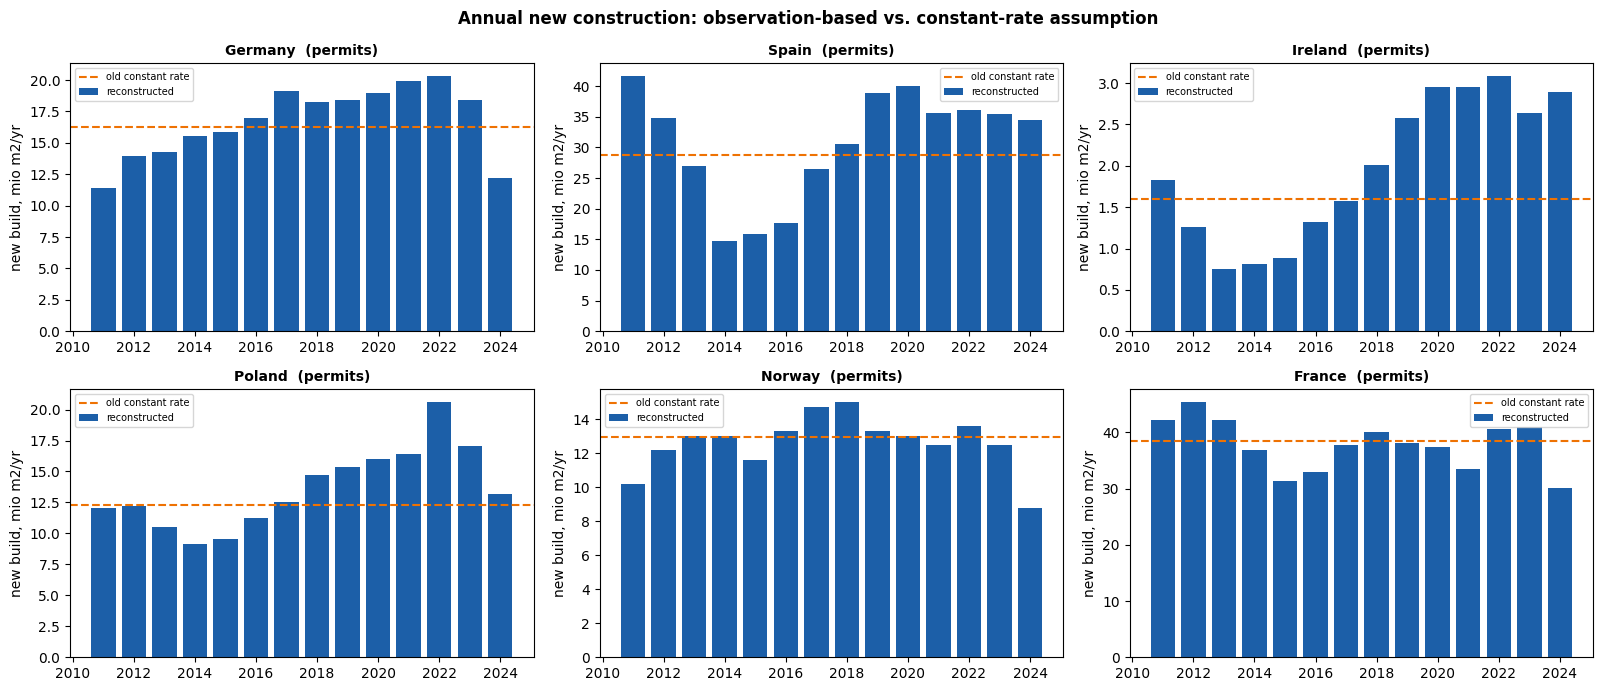

In [38]:
# reconstructed new-build activity vs the old constant-rate assumption
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, country in zip(axes.flatten(), ["Germany", "Spain", "Ireland", "Poland", "Norway", "France"]):
    nb = hist_newbuild[country]
    yrs = [y for y in range(2011, 2025) if y in nb]
    ax.bar(yrs, [nb[y] / 1e6 for y in yrs], color="#1C5FA8", label="reconstructed")
    flat = (bso.loc[country, PERIOD_COLS["2011-2020"]] *
            bso.loc[country, "gesamtfläche_m2"]) / 10 / 1e6
    ax.axhline(flat, color="#EE7203", ls="--", lw=1.5, label="old constant rate")
    ax.set_title(f"{country}  ({hist_meta[country]})", fontweight="bold", fontsize=10)
    ax.set_ylabel("new build, mio m2/yr")
    ax.legend(fontsize=7)
plt.suptitle("Annual new construction: observation-based vs. constant-rate assumption",
             fontweight="bold")
plt.tight_layout()
plt.show()

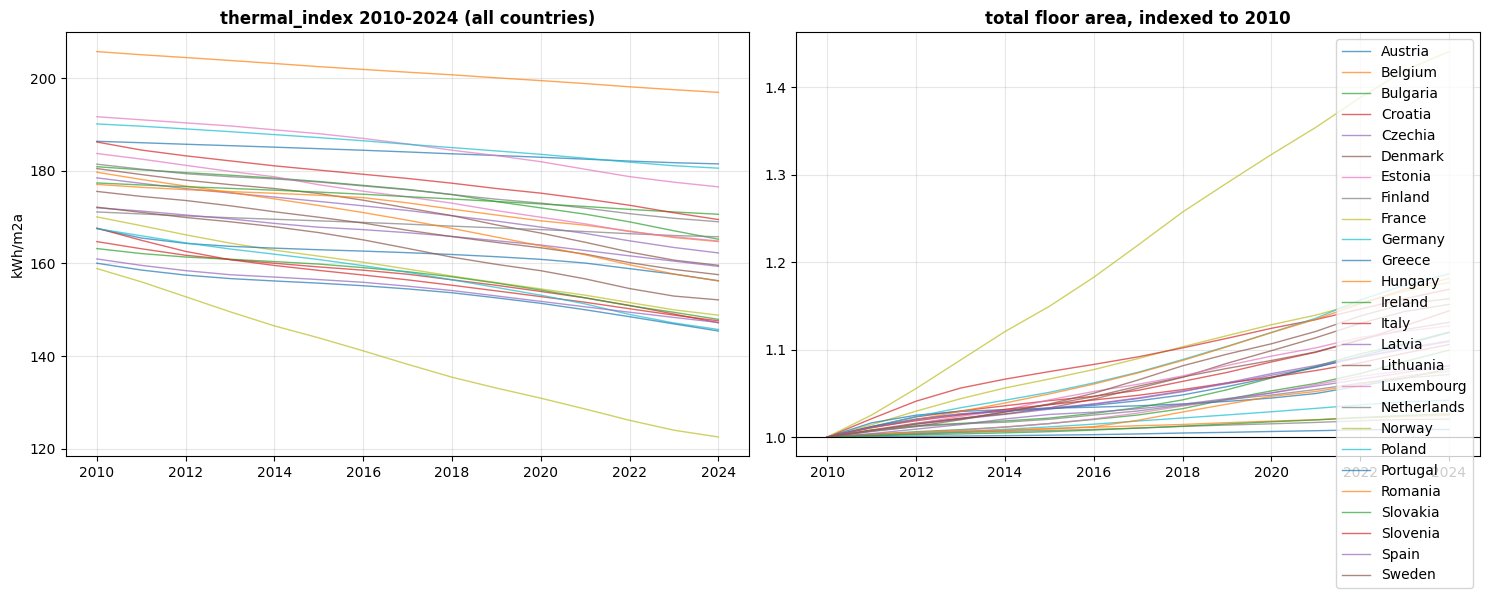

within-country variation of thermal_index over 2010-2024 (% of max):
  mean 9.08 %   min 2.62 %   max 22.88 %

(the previous constant-rate version produced almost no within-country variation, which is why the ln_thermal_index coefficient was weakly identified)


In [39]:
# historical thermal index and total floor area
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for country in ALL_COUNTRIES:
    d = floor_hist[floor_hist.country == country].sort_values("year")
    axes[0].plot(d.year, d.thermal_index, lw=1, alpha=0.7, label=country)
    axes[1].plot(d.year, d.total_floor_m2 / d.total_floor_m2.iloc[0], lw=1, alpha=0.7, label=country)
axes[0].set_title("thermal_index 2010-2024 (all countries)", fontweight="bold")
axes[0].set_ylabel("kWh/m2a")
axes[1].set_title("total floor area, indexed to 2010", fontweight="bold")
axes[1].axhline(1.0, color="k", lw=0.8)
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

var = (floor_hist.groupby("country")["thermal_index"]
       .agg(["min", "max"]).assign(range_pct=lambda d: (d["max"] - d["min"]) / d["max"] * 100))
print("within-country variation of thermal_index over 2010-2024 (% of max):")
print(f"  mean {var.range_pct.mean():.2f} %   min {var.range_pct.min():.2f} %   "
      f"max {var.range_pct.max():.2f} %")
print("\n(the previous constant-rate version produced almost no within-country variation, "
      "which is why the ln_thermal_index coefficient was weakly identified)")

---
## 4. Projection 2025-2060

### 4.1 Estimating the income elasticity of floor area per capita

Instead of assuming ε, we estimate it from the reconstructed historical panel, using
within-country variation only (country fixed effects), so ε reflects how floor area per capita
responds to income inside a country over time, not cross-sectional rich-vs-poor differences:

$$\ln \text{FloorPerCapita}_{c,t} = \alpha_c + \varepsilon \cdot \ln \text{GDP}_{pc,c,t} + u_{c,t}$$

The estimate is only used if it falls in a plausible range, otherwise we fall back to the
literature value. With only 15 years and a slow-moving dependent variable this is indicative
rather than precise - §6 treats ε as a sensitivity parameter.

In [40]:
est = (floor_hist.merge(drivers, on=["country", "year"], how="inner")
       .assign(floor_pc=lambda d: d.total_floor_m2 / (d.population_Mio * 1e6)))
est["ln_floor_pc"] = np.log(est["floor_pc"])
est["ln_gdp_pc"]   = np.log(est["gdp_per_capita_USD"])

# within transformation (country fixed effects)
est["ln_floor_pc_dm"] = est["ln_floor_pc"] - est.groupby("country")["ln_floor_pc"].transform("mean")
est["ln_gdp_pc_dm"]   = est["ln_gdp_pc"]   - est.groupby("country")["ln_gdp_pc"].transform("mean")

x, y = est["ln_gdp_pc_dm"].values, est["ln_floor_pc_dm"].values
eps_hat = float((x * y).sum() / (x * x).sum())
resid   = y - eps_hat * x
n, k_fe = len(x), est.country.nunique()
se_hat  = float(np.sqrt((resid @ resid) / (n - k_fe - 1) / (x @ x)))
r2_w    = 1 - (resid @ resid) / ((y - y.mean()) @ (y - y.mean()))

print(f"within-country elasticity  eps = {eps_hat:.3f}  (se {se_hat:.3f}, "
      f"t {eps_hat/se_hat:.2f}, within-R2 {r2_w:.3f}, N {n})")

if EPSILON_BOUNDS[0] <= eps_hat <= EPSILON_BOUNDS[1]:
    EPSILON = eps_hat
    print(f"-> using the estimated value: EPSILON = {EPSILON:.3f}")
else:
    EPSILON = EPSILON_DEFAULT
    print(f"!! estimate outside the plausible range {EPSILON_BOUNDS} "
          f"-> using the fallback EPSILON = {EPSILON:.3f}")

within-country elasticity  eps = 0.264  (se 0.016, t 16.09, within-R2 0.416, N 390)
-> using the estimated value: EPSILON = 0.264


### 4.2 Projection algorithm

Per year and scenario, in order:

1. **Demand target**
   $\text{Target}(t) = \text{Pop}(t)\cdot \text{FPC}(2024)\cdot
   \big(\text{GDP}_{pc}(t)/\text{GDP}_{pc}(2024)\big)^{\varepsilon}$
2. **Demolition** - each cohort loses its own hazard rate; renovated area inherits its source
   cohort's hazard (a renovated 1950s building is still structurally a 1950s building).
3. **New construction** - residual needed to hit the target, floored at zero, added to
   `post-2020`.
4. **Renovation** - `rate(t) x total stock` moved worst-first from renovatable cohorts into
   their `ren_` counterparts (mirrors the EPBD minimum-energy-performance-standard logic of
   targeting the worst buildings first). Already-renovated area isn't renovated again within the
   horizon (renovation cycles typically run 30-40 years).
5. **Thermal index** - area-weighted average intensity over all cohorts.

Projection starts from the reconstructed 2024 state, not the 2020 snapshot, so history and
projection join without a jump.

In [41]:
def renovation_rate_path(year, r_2030, r_2025=RENOVATION_START, r_2050=None):
    """Piecewise-linear ramp of the annual energy-renovation rate."""
    if r_2050 is None:
        r_2050 = r_2030
    if year <= 2025:
        return r_2025
    if year <= 2030:
        return r_2025 + (r_2030 - r_2025) * (year - 2025) / 5.0
    if year <= 2050:
        return r_2030 + (r_2050 - r_2030) * (year - 2030) / 20.0
    return r_2050


def project_stock(state_start, floor_pc_start, pop, gdp_pc, gdp_pc_start,
                  epsilon, r_2030, years=PROJ_YEARS,
                  demolition=DEMOLITION_RATE, renovatable=RENOVATABLE,
                  r_2025=RENOVATION_START, r_2050=None):
    """Forward projection of one country under one scenario.

    Mass balance per year:
        stock(t) = stock(t-1) - demolition(t) + new_build(t)
    with renovation shifting area between cohorts without changing the total.
    """
    states = {}
    cur = dict(state_start)
    for y in years:
        # 1. demand-driven target
        floor_pc = floor_pc_start * (gdp_pc[y] / gdp_pc_start) ** epsilon
        target   = pop[y] * floor_pc

        # 2. age-dependent demolition
        for c in list(cur):
            base = c[len(REN_PREFIX):] if c.startswith(REN_PREFIX) else c
            cur[c] *= (1.0 - demolition.get(base, 0.0))
        after_demo = sum(cur.values())

        # 3. new construction = residual, never negative
        cur[NEW_COHORT] += max(0.0, target - after_demo)

        # 4. renovation: mass-preserving shift, worst cohorts first
        to_renovate = renovation_rate_path(y, r_2030, r_2025, r_2050) * sum(cur.values())
        for c in renovatable:
            if to_renovate <= 1e-9:
                break
            take = min(cur.get(c, 0.0), to_renovate)
            cur[c] -= take
            cur[REN_PREFIX + c] += take
            to_renovate -= take

        states[y] = dict(cur)
    return states

### 4.3 Run the projection for all countries and scenarios

In [42]:
drv = drivers.set_index(["country", "year"])

def run_projection(epsilon=None, scenario_renovation=None, demolition=None,
                   depth=None, years=PROJ_YEARS):
    """Project all countries under all scenarios. Returns a tidy DataFrame."""
    epsilon             = EPSILON if epsilon is None else epsilon
    scenario_renovation = SCENARIO_RENOVATION if scenario_renovation is None else scenario_renovation
    demolition          = DEMOLITION_RATE if demolition is None else demolition
    depth               = RENOVATION_DEPTH if depth is None else depth

    frames = []
    for scenario, r30 in scenario_renovation.items():
        states_by_country = {}
        for country in ALL_COUNTRIES:
            s24  = hist_states[country][2024]
            pop  = {y: drv.loc[(country, y), "population_Mio"] * 1e6 for y in years}
            gdp  = {y: drv.loc[(country, y), "gdp_per_capita_USD"]   for y in years}
            pop24 = drv.loc[(country, 2024), "population_Mio"] * 1e6
            gdp24 = drv.loc[(country, 2024), "gdp_per_capita_USD"]
            fpc24 = sum(s24.values()) / pop24
            states_by_country[country] = project_stock(
                s24, fpc24, pop, gdp, gdp24, epsilon, r30,
                years=years, demolition=demolition)
        f = states_to_frame(states_by_country, scenario=scenario)
        # recompute the thermal index if a non-default depth is being tested
        if depth != RENOVATION_DEPTH:
            ti = []
            for country, states in states_by_country.items():
                for year, area in states.items():
                    ti.append({"country": country, "year": year,
                               "thermal_index": thermal_index(area, depth=depth)})
            f = (f.drop(columns=["thermal_index"])
                   .merge(pd.DataFrame(ti), on=["country", "year"]))
        frames.append(f)
    return pd.concat(frames, ignore_index=True)

floor_proj = run_projection()
print("projection panel:", floor_proj.shape)
floor_proj[(floor_proj.country == "Germany") & (floor_proj.scenario == "KKO")][
    ["year", "total_floor_m2", "thermal_index"]].head()

projection panel: (1248, 19)


,year,total_floor_m2,thermal_index
108,2025,3.865644e+09,179.115077
109,2026,3.875086e+09,177.442938
110,2027,3.879469e+09,175.790054
111,2028,3.882841e+09,174.005406
112,2029,3.885715e+09,172.070242


In [43]:
# continuity check across the 2024/2025 boundary
jump = []
for country in ALL_COUNTRIES:
    ti24 = floor_hist.loc[(floor_hist.country == country) & (floor_hist.year == 2024),
                          "thermal_index"].iloc[0]
    ti25 = floor_proj.loc[(floor_proj.country == country) & (floor_proj.year == 2025) &
                          (floor_proj.scenario == "KKO"), "thermal_index"].iloc[0]
    jump.append({"country": country, "ti_2024": ti24, "ti_2025": ti25,
                 "rel_jump_%": (ti25 - ti24) / ti24 * 100})
jump = pd.DataFrame(jump).set_index("country")
print("thermal_index continuity 2024 -> 2025 (KKO):")
print(f"  mean {jump['rel_jump_%'].mean():+.2f} %   worst {jump['rel_jump_%'].abs().max():.2f} %")
display(jump.sort_values("rel_jump_%").head(5).round(2))

thermal_index continuity 2024 -> 2025 (KKO):
  mean -1.23 %   worst 2.42 %


,ti_2024,ti_2025,rel_jump_%
country,,,
Ireland,147.94,144.35,-2.42
Luxembourg,164.85,161.67,-1.93
Spain,147.27,144.54,-1.85
Portugal,145.42,142.97,-1.69
Croatia,147.20,144.77,-1.65


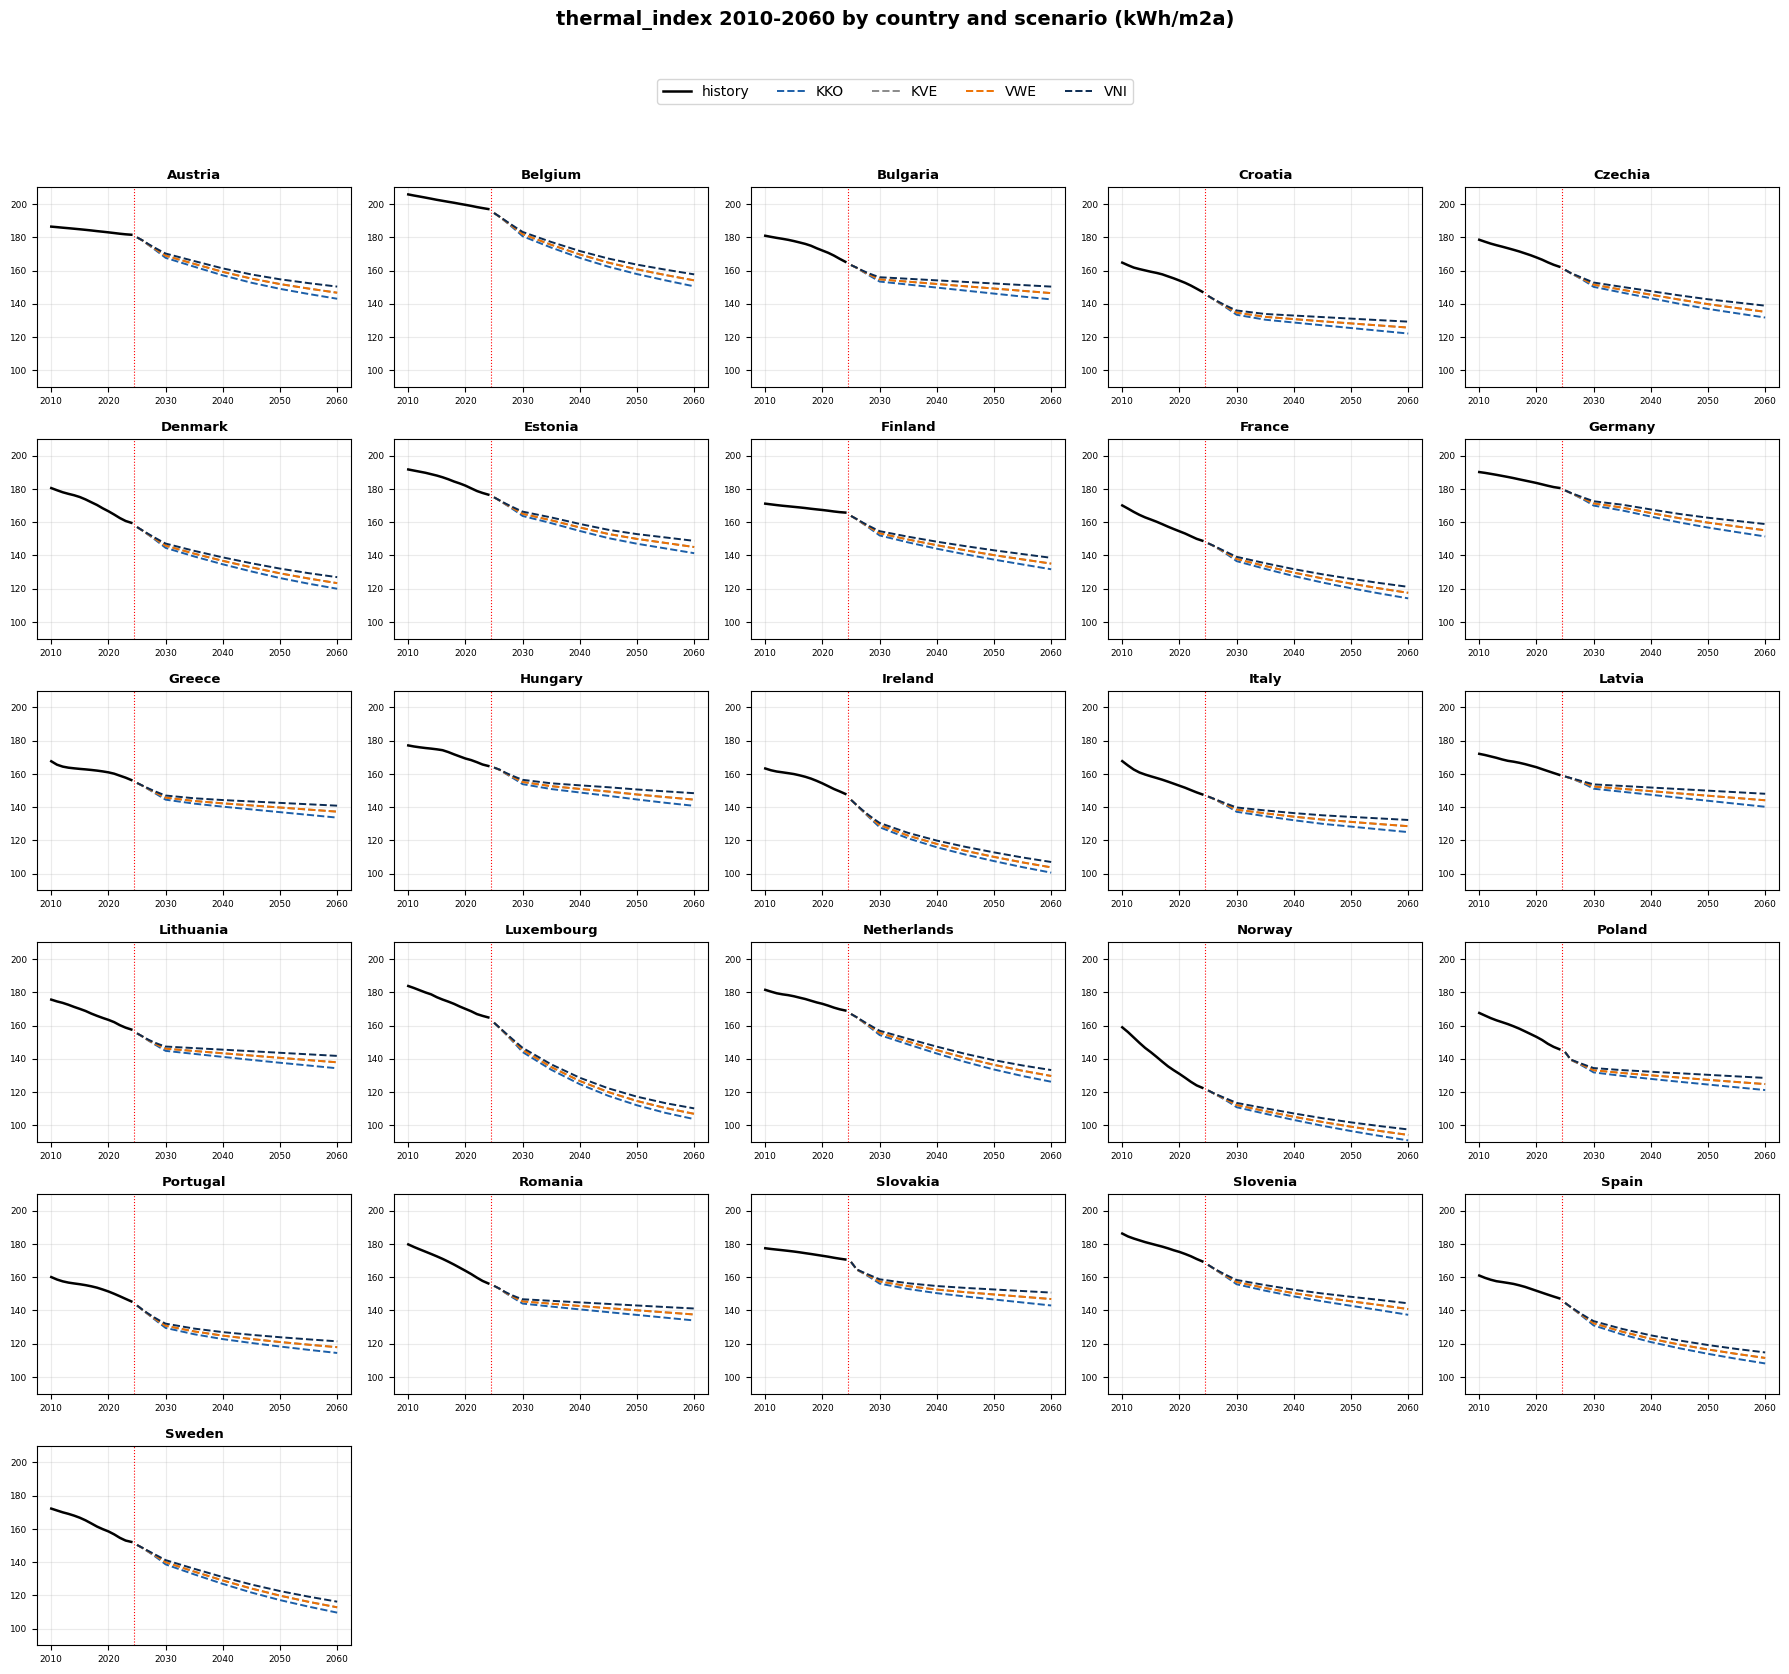

In [44]:
COL = {"KKO": "#1C5FA8", "KVE": "#8A8A8A", "VWE": "#EE7203", "VNI": "#0B2B52"}

n_cols = 5
n_rows = math.ceil(len(ALL_COUNTRIES) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.6, n_rows * 2.6))
axes = axes.flatten()
for ax, country in zip(axes, ALL_COUNTRIES):
    h = floor_hist[floor_hist.country == country].sort_values("year")
    ax.plot(h.year, h.thermal_index, color="black", lw=1.8, label="history")
    for sc in SCENARIOS:
        p = floor_proj[(floor_proj.country == country) &
                       (floor_proj.scenario == sc)].sort_values("year")
        ax.plot(p.year, p.thermal_index, color=COL[sc], lw=1.4, ls="--", label=sc)
    ax.axvline(2024.5, color="red", ls=":", lw=0.8)
    ax.set_title(country, fontsize=9.5, fontweight="bold")
    ax.tick_params(labelsize=6.5)
    ax.grid(alpha=0.25)
    ax.set_ylim(90,210)
for ax in axes[len(ALL_COUNTRIES):]:
    ax.set_visible(False)
h_, l_ = axes[0].get_legend_handles_labels()
fig.legend(h_, l_, loc="upper center", ncol=5, fontsize=10, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("thermal_index 2010-2060 by country and scenario (kWh/m2a)",
             fontsize=14, fontweight="bold", y=1.07)
plt.tight_layout()
plt.show()

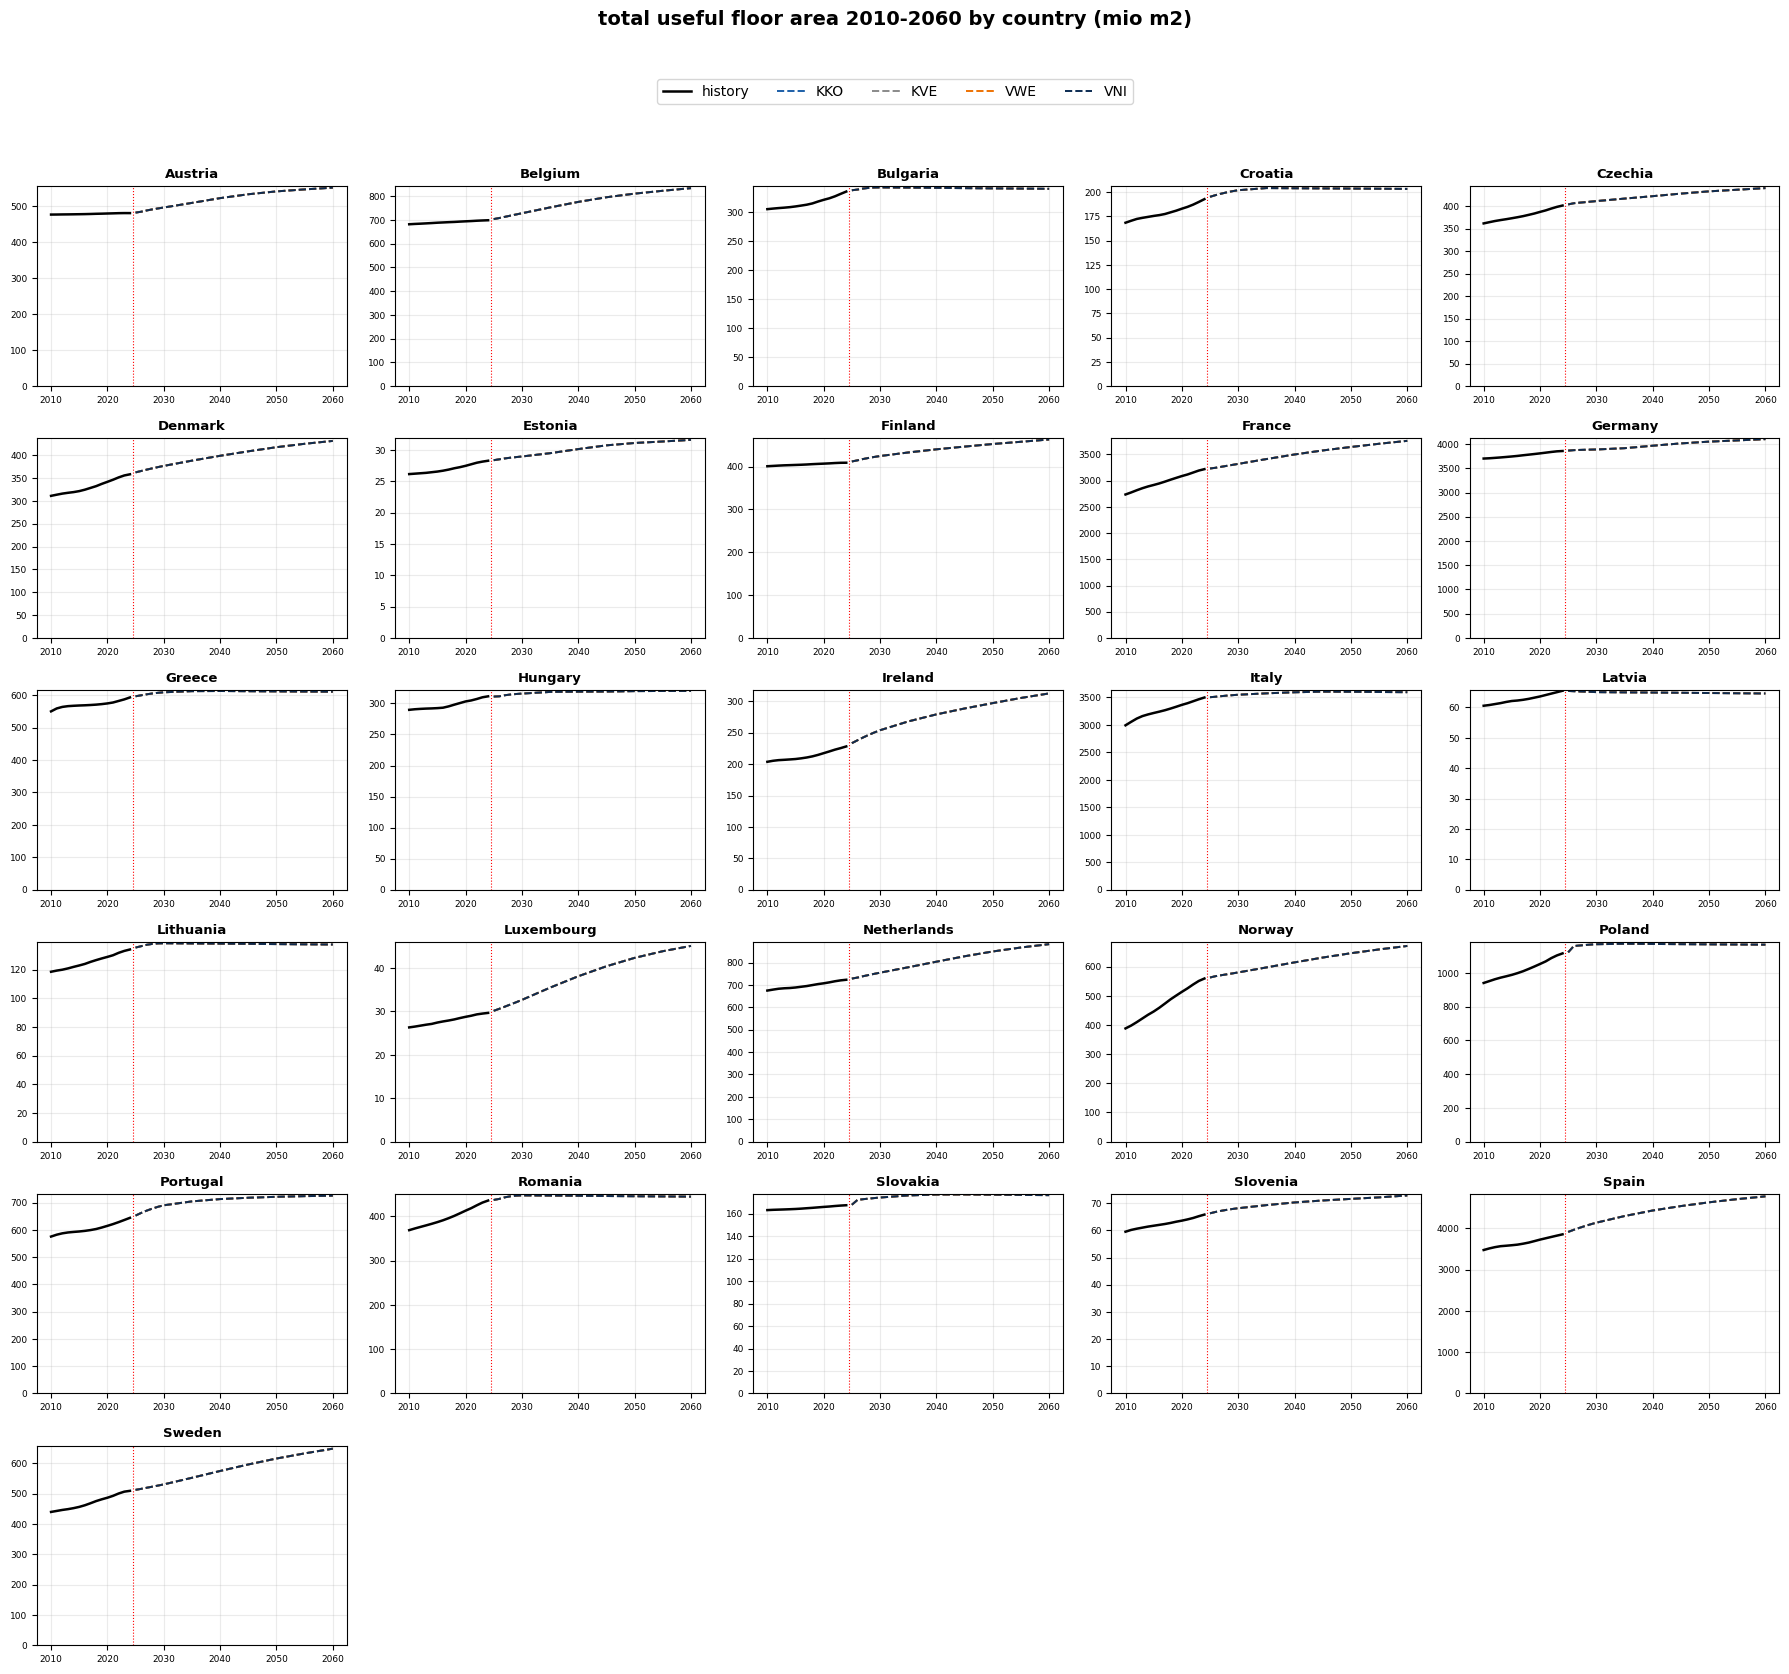

In [45]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.6, n_rows * 2.6))
axes = axes.flatten()
for ax, country in zip(axes, ALL_COUNTRIES):
    h = floor_hist[floor_hist.country == country].sort_values("year")
    ax.plot(h.year, h.total_floor_m2 / 1e6, color="black", lw=1.8, label="history")
    for sc in SCENARIOS:
        p = floor_proj[(floor_proj.country == country) &
                       (floor_proj.scenario == sc)].sort_values("year")
        ax.plot(p.year, p.total_floor_m2 / 1e6, color=COL[sc], lw=1.4, ls="--", label=sc)
    ax.axvline(2024.5, color="red", ls=":", lw=0.8)
    ax.set_title(country, fontsize=9.5, fontweight="bold")
    ax.tick_params(labelsize=6.5)
    ax.grid(alpha=0.25)
    ax.set_ylim(0,)
for ax in axes[len(ALL_COUNTRIES):]:
    ax.set_visible(False)
h_, l_ = axes[0].get_legend_handles_labels()
fig.legend(h_, l_, loc="upper center", ncol=5, fontsize=10, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("total useful floor area 2010-2060 by country (mio m2)",
             fontsize=14, fontweight="bold", y=1.07)
plt.tight_layout()
plt.show()

---
## 5. Sensitivity analysis

The projection is entirely separate from the historical training data, so the model coefficients
don't change with anything varied here - only the projected inputs do. That's what makes this
interpretable: any change in projected demand traces back to the input assumption, not a
re-estimated model.

Three parameters, varied one at a time around baseline:

| Parameter | Baseline | Range tested | Why |
|---|---|---|---|
| ε (income elasticity) | estimated in §4.1 | 0.10 - 0.45 | drives total floor area |
| demolition hazard | §1.2 step values | 0.5x - 2x | drives how fast old cohorts leave |
| renovation depth | 0.35 | 0.20 - 0.60 | drives how much the thermal index falls |

Renovation *rate* isn't varied here - it's already the scenario dimension (KKO/KVE/VWE/VNI) and
its spread shows up in the plots above.

In [46]:
SENS_YEARS = [2030, 2040, 2050, 2060]

def summarise(df, label):
    """EU-26 aggregate floor area and area-weighted thermal index, KKO scenario."""
    d = df[df.scenario == "KKO"] if "scenario" in df.columns else df
    g = (d[d.year.isin(SENS_YEARS)]
         .assign(w=lambda x: x.total_floor_m2 * x.thermal_index)
         .groupby("year")
         .agg(total_floor_bn_m2=("total_floor_m2", lambda s: s.sum() / 1e9),
              w=("w", "sum"), a=("total_floor_m2", "sum")))
    g["thermal_index"] = g["w"] / g["a"]
    g = g[["total_floor_bn_m2", "thermal_index"]].round(2)
    g.columns = pd.MultiIndex.from_product([[label], g.columns])
    return g

base = summarise(floor_proj, "baseline")

# --- epsilon ------------------------------------------------------------------
eps_runs = {f"eps={e}": summarise(run_projection(epsilon=e), f"eps={e}")
            for e in [0.10, 0.45]}
print("SENSITIVITY: income elasticity of floor area per capita")
display(pd.concat([base] + list(eps_runs.values()), axis=1))

SENSITIVITY: income elasticity of floor area per capita


baseline                         eps=0.1                        eps=0.45              
     total_floor_bn_m2 thermal_index total_floor_bn_m2 thermal_index total_floor_bn_m2 thermal_index
year                                                                                                
2030             23.73        144.36             23.41        145.92             24.12        142.55
2040             24.65        136.53             23.87        139.98             25.70        132.18
2050             25.32        130.17             24.16        135.04             26.99        123.94
2060             25.80        124.85             24.26        131.06             28.13        116.84

In [47]:
# --- demolition hazard --------------------------------------------------------
demo_runs = {}
for f in [0.5, 2.0]:
    dem = {k: v * f for k, v in DEMOLITION_RATE.items()}
    demo_runs[f"demo x{f}"] = summarise(run_projection(demolition=dem), f"demo x{f}")
print("SENSITIVITY: demolition hazard scaling")
display(pd.concat([base] + list(demo_runs.values()), axis=1))

# --- renovation depth ---------------------------------------------------------
depth_runs = {f"depth={d}": summarise(run_projection(depth=d), f"depth={d}")
              for d in [0.20, 0.60]}
print("\nSENSITIVITY: renovation depth")
display(pd.concat([base] + list(depth_runs.values()), axis=1))

SENSITIVITY: demolition hazard scaling


baseline                       demo x0.5                       demo x2.0              
     total_floor_bn_m2 thermal_index total_floor_bn_m2 thermal_index total_floor_bn_m2 thermal_index
year                                                                                                
2030             23.73        144.36             23.73        144.94             23.73        143.22
2040             24.65        136.53             24.65        137.24             24.64        135.12
2050             25.32        130.17             25.33        131.00             25.31        128.54
2060             25.80        124.85             25.82        125.78             25.78        123.03


SENSITIVITY: renovation depth


baseline                       depth=0.2                       depth=0.6              
     total_floor_bn_m2 thermal_index total_floor_bn_m2 thermal_index total_floor_bn_m2 thermal_index
year                                                                                                
2030             23.73        144.36             23.73        147.68             23.73        138.84
2040             24.65        136.53             24.65        141.17             24.65        128.79
2050             25.32        130.17             25.32        136.10             25.32        120.29
2060             25.80        124.85             25.80        132.04             25.80        112.89

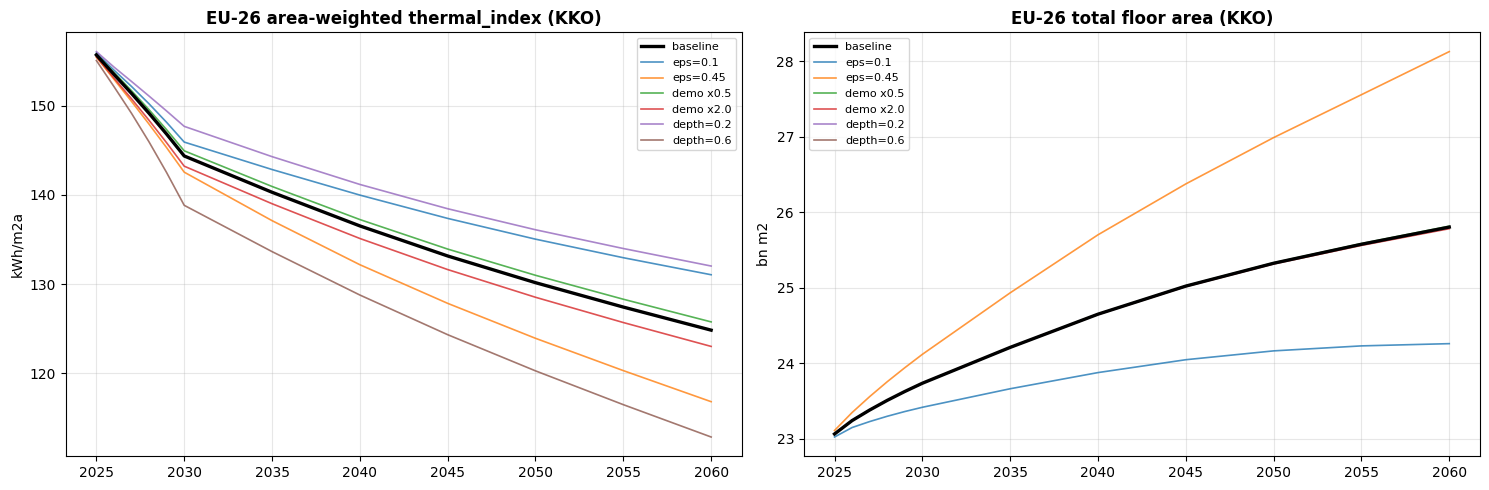

In [48]:
# visual summary: EU-26 thermal index bandwidth under all variants
variants = {"baseline": floor_proj}
for e in [0.10, 0.45]:
    variants[f"eps={e}"] = run_projection(epsilon=e)
for f in [0.5, 2.0]:
    variants[f"demo x{f}"] = run_projection(demolition={k: v * f for k, v in DEMOLITION_RATE.items()})
for d in [0.20, 0.60]:
    variants[f"depth={d}"] = run_projection(depth=d)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for name, df in variants.items():
    d = df[df.scenario == "KKO"].copy()
    d["w"] = d.total_floor_m2 * d.thermal_index
    g = d.groupby("year").agg(w=("w", "sum"), a=("total_floor_m2", "sum"))
    style = dict(lw=2.4, color="black", zorder=5) if name == "baseline" else dict(lw=1.2, alpha=0.8)
    axes[0].plot(g.index, g.w / g.a, label=name, **style)
    axes[1].plot(g.index, g.a / 1e9, label=name, **style)
axes[0].set_title("EU-26 area-weighted thermal_index (KKO)", fontweight="bold")
axes[0].set_ylabel("kWh/m2a")
axes[1].set_title("EU-26 total floor area (KKO)", fontweight="bold")
axes[1].set_ylabel("bn m2")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 6. Comparison with the previous implementation

The previous `build_floor_panel` had three properties this notebook changes:

1. new build was a constant rate implied by the 2011-2020 cohort divided by ten;
2. total floor area was independent of population and income;
3. the "renovation rate" removed area from the stock, acting as a second demolition term rather
   than a fabric improvement.

Chart below shows what that changes for the two features the models actually use.

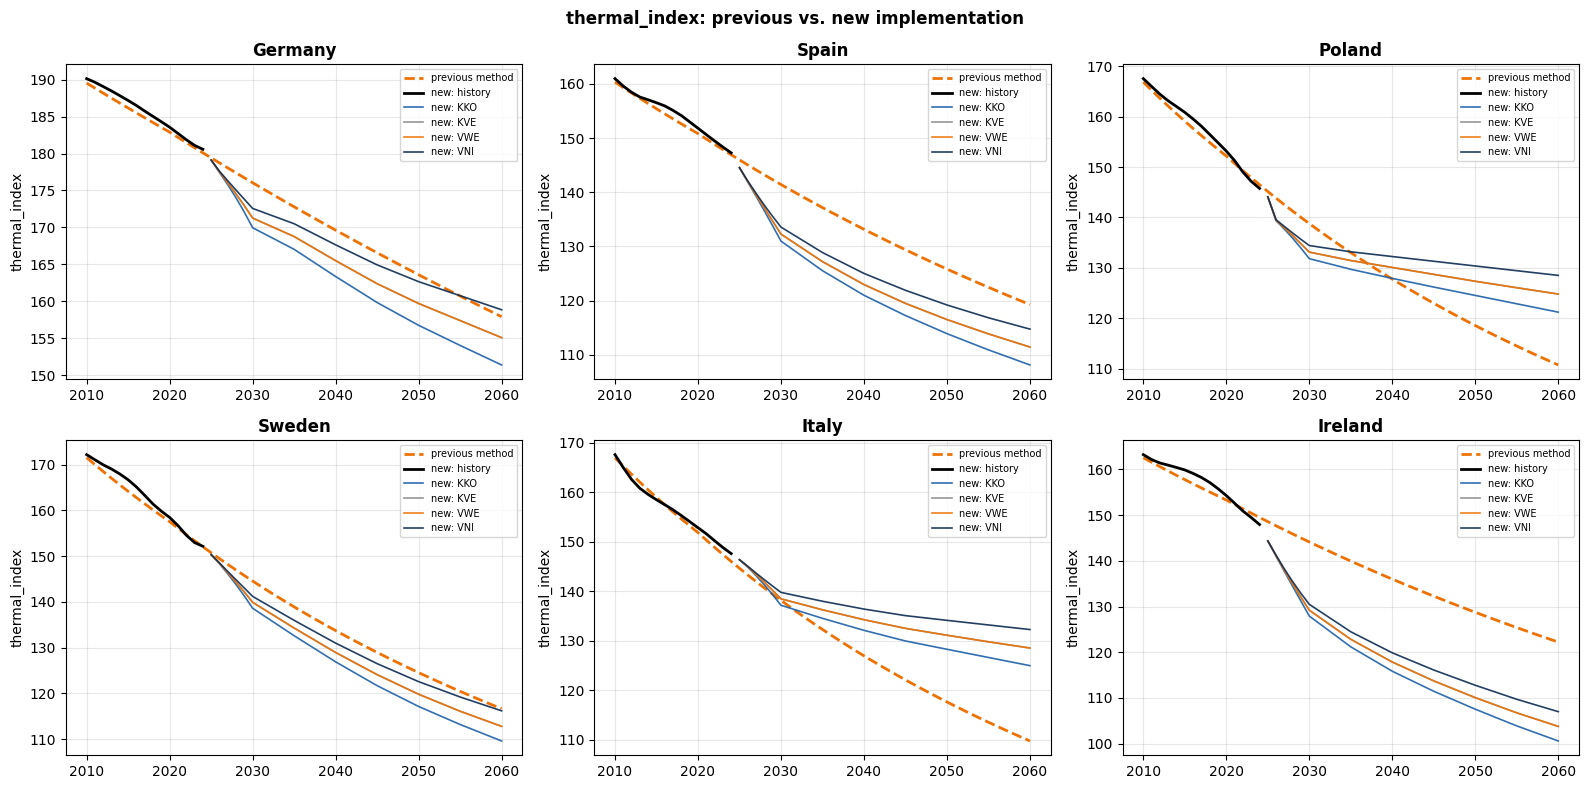

In [49]:
# replicate the previous method for comparison
OLD_INTENSITY = {"0-1945": 250, "1946-1969": 230, "1970-1979": 170, "1980-1989": 135,
                 "1990-1999": 110, "2000-2010": 85, "2011-now": 50}
OLD_RENOVATION_RATE = 0.001
OLD_PERIODS = ["0-1945", "1946-1969", "1970-1979", "1980-1989", "1990-1999", "2000-2010"]

def build_floor_panel_old(bso, years=range(2010, 2061)):
    out = []
    for country, r in bso.iterrows():
        At = r["gesamtfläche_m2"]
        A2020 = {p: r[c] * At for p, c in
                 {**{k: PERIOD_COLS[k] for k in OLD_PERIODS}, "2011-now": "anteil 2011-now"}.items()}
        annual_new = A2020["2011-now"] / 10
        annual_ren = At * OLD_RENOVATION_RATE
        for y in years:
            area = {p: A2020[p] for p in OLD_PERIODS}
            area["2011-now"]  = annual_new * min(max(0, y - 2010), 10)
            area["post-2020"] = annual_new * max(0, y - 2020)
            remaining = annual_ren * max(0, y - 2010)
            for p in OLD_PERIODS:
                if remaining <= 0:
                    break
                sub = min(area[p], remaining)
                area[p] -= sub
                remaining -= sub
            tot = sum(area.values())
            intens = {**OLD_INTENSITY, "post-2020": 35}
            out.append({"country": country, "year": y, "total_floor_m2": tot,
                        "thermal_index": sum(area[p] * intens[p] for p in area) / tot})
    return pd.DataFrame(out)

floor_old = build_floor_panel_old(bso)
floor_new = pd.concat([floor_hist.assign(scenario="HIST"), floor_proj], ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, country in zip(axes.flatten(), ["Germany", "Spain", "Poland", "Sweden", "Italy", "Ireland"]):
    o = floor_old[floor_old.country == country].sort_values("year")
    ax.plot(o.year, o.thermal_index, color="#EE7203", lw=2, ls="--", label="previous method")
    h = floor_new[(floor_new.country == country) & (floor_new.scenario == "HIST")].sort_values("year")
    ax.plot(h.year, h.thermal_index, color="black", lw=2, label="new: history")
    for sc in SCENARIOS:
        p = floor_new[(floor_new.country == country) & (floor_new.scenario == sc)].sort_values("year")
        ax.plot(p.year, p.thermal_index, color=COL[sc], lw=1.2, ls="-", alpha=0.9, label=f"new: {sc}")
    ax.set_title(country, fontweight="bold")
    ax.set_ylabel("thermal_index")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
plt.suptitle("thermal_index: previous vs. new implementation", fontweight="bold")
plt.tight_layout()
plt.show()

---
## 7. Export

The exported panel uses `scenario == "HIST"` for the observation-based years 2010-2024. Both
model notebooks read this one file:

* `hist` (2010-2024) joins on `scenario == "HIST"`;
* the single-pathway `proj` joins on one chosen baseline scenario;
* `proj_scenarios` merges on `country`, `year` and `scenario`.

Columns:

| Column | Meaning |
|---|---|
| `country`, `year`, `scenario` | keys (`scenario == "HIST"` for 2010-2024) |
| `total_floor_m2` | total useful floor area |
| `thermal_index` | area-weighted heat-demand intensity, kWh/m²a |
| `ln_total_floor`, `ln_thermal_index` | log transforms for the PanelOLS models |
| `share_*` | floor-area share of each cohort (incl. `ren_*`), diagnostics only |
| `hist_method` | `permits` or `flat_fallback`, historical rows only |

In [50]:
floor_panel_out = pd.concat(
    [floor_hist.assign(scenario="HIST"),
     floor_proj.assign(hist_method=np.nan)],
    ignore_index=True)

floor_panel_out["ln_total_floor"]   = np.log1p(floor_panel_out["total_floor_m2"])
floor_panel_out["ln_thermal_index"] = np.log1p(floor_panel_out["thermal_index"])

share_cols = sorted([c for c in floor_panel_out.columns if c.startswith("share_")])
floor_panel_out = floor_panel_out[
    ["country", "year", "scenario", "total_floor_m2", "thermal_index",
     "ln_total_floor", "ln_thermal_index", "hist_method"] + share_cols
].sort_values(["country", "scenario", "year"]).reset_index(drop=True)

# --- final integrity checks ---------------------------------------------------
assert floor_panel_out["total_floor_m2"].gt(0).all(), "non-positive floor area"
assert floor_panel_out["thermal_index"].between(20, 300).all(), "implausible thermal index"
for c in ALL_COUNTRIES:
    d = floor_panel_out[(floor_panel_out.country == c) & (floor_panel_out.scenario == "HIST")]
    assert sorted(d.year) == HIST_YEARS, f"history incomplete for {c}"
    for sc in SCENARIOS:
        d = floor_panel_out[(floor_panel_out.country == c) & (floor_panel_out.scenario == sc)]
        assert sorted(d.year) == PROJ_YEARS, f"projection incomplete for {c}/{sc}"
sh = floor_panel_out[share_cols].sum(axis=1)
assert np.allclose(sh, 1.0, atol=1e-6), "cohort shares do not sum to 1"

os.makedirs(os.path.dirname(PATH_OUT), exist_ok=True)
floor_panel_out.to_csv(PATH_OUT, index=False)

print(f"written: {PATH_OUT}")
print(f"  {len(floor_panel_out)} rows = {len(ALL_COUNTRIES)} countries x "
      f"({len(HIST_YEARS)} hist + {len(SCENARIOS)}x{len(PROJ_YEARS)} proj)")
print(f"  epsilon = {EPSILON:.3f} | renovation depth = {RENOVATION_DEPTH} | "
      f"renovation rates 2030 = {SCENARIO_RENOVATION}")
floor_panel_out.tail()

written: Data - raw/prepared_data/floor_panel_2010_2060.csv
  1638 rows = 26 countries x (15 hist + 4x12 proj)
  epsilon = 0.264 | renovation depth = 0.35 | renovation rates 2030 = {'KKO': 0.02, 'KVE': 0.015, 'VWE': 0.015, 'VNI': 0.01}


,country,year,scenario,total_floor_m2,thermal_index,ln_total_floor,ln_thermal_index,hist_method,share_0-1945,share_1946-1969,share_1970-1979,share_1980-1989,share_1990-1999,share_2000-2010,share_2011-2020,share_post-2020,share_ren_0-1945,share_ren_1946-1969,share_ren_1970-1979,share_ren_1980-1989,share_ren_1990-1999,share_ren_2000-2010
1633,Sweden,2040,VWE,5.747899e+08,128.952562,20.169515,4.867169,NaN,0.053027,0.131623,0.132189,0.122996,0.105923,0.102167,0.090967,0.164457,0.096651,0.000000,0.0,0.0,0.0,0.0
1634,Sweden,2045,VWE,5.962872e+08,124.111678,20.206233,4.829207,NaN,0.035962,0.126624,0.127296,0.118502,0.102104,0.098483,0.087688,0.195453,0.107888,0.000000,0.0,0.0,0.0,0.0
1635,Sweden,2050,VWE,6.158630e+08,119.834069,20.238535,4.794418,NaN,0.019714,0.122354,0.123126,0.114678,0.098859,0.095353,0.084900,0.221870,0.119145,0.000000,0.0,0.0,0.0,0.0
1636,Sweden,2055,VWE,6.328274e+08,116.122479,20.265708,4.763220,NaN,0.004128,0.118836,0.119706,0.111548,0.096209,0.092797,0.082624,0.243549,0.130603,0.000000,0.0,0.0,0.0,0.0
1637,Sweden,2060,VWE,6.483906e+08,112.821884,20.290004,4.734635,NaN,0.000000,0.104769,0.116716,0.108816,0.093899,0.090569,0.080641,0.262503,0.131103,0.010983,0.0,0.0,0.0,0.0


---
## 8. Assumption log

Everything below is an assumption, not an observation - each line needs a citation in the thesis
text.

| # | Assumption | Value | Basis / to verify |
|---|---|---|---|
| A1 | Cohort heat-demand intensities | 250 … 50 kWh/m²a | to calibrate against TABULA/EPISCOPE national typologies |
| A2 | New-build intensity from 2021 | 35 kWh/m²a | NZEB requirement, EPBD Art. 9 |
| A3 | Demolition hazard by cohort age | 0.30 … 0 %/yr | step approximation of a Weibull hazard (Sandberg et al. 2014; Miatto et al. 2017); stock-wide average to check against national statistics |
| A4 | Renovation rate 2025 | 1.0 %/yr | EU weighted energy-renovation rate (EC / BPIE) |
| A5 | Renovation rate 2030 by scenario | 1.0 – 2.0 %/yr | Renovation Wave target COM(2020) 662; BPIE (2021) |
| A6 | Renovation depth | 35 % demand reduction | mix of shallow and deep renovation; deep-renovation share ~0.2 pp of ~1 %/yr (BPIE 2021) |
| A7 | Renovation order | worst cohorts first | EPBD minimum energy performance standards target worst-performing buildings |
| A8 | Income elasticity of floor area per capita | estimated (§4.1), fallback 0.25 | within-country estimate on the reconstructed panel |
| A9 | Permit-to-completion lag | 1 year | Eurostat metadata on building permits |
| A10 | Realisation rate of permits | absorbed in the level calibration | not separately identified |
| A11 | No renovation in 2010-2024 | – | deep renovation ~0.2 %/yr over the period, i.e. <3 % of stock cumulatively |
| A12 | Falling demand does not trigger demolition | – | excess area becomes vacant; demolition depends on age only |

**Known limitations**

* BSO covers useful floor area of the whole stock; the permit series may split
  residential/non-residential differently - check `PERMIT_FILTER` matches the BSO scope.
* No vacancy modelled explicitly - in shrinking countries the "excess" area stays in the stock
  and is implicitly treated as heated, slightly overstating demand there.
* Renovation depth is a single EU-wide average; national programmes differ a lot.
* ε is estimated on only 15 years of a slow-moving variable - treat as indicative.